In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

Data path: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\data\raw


# 1. Phân tích Revenue

## 1.1. EDA nâng cao

#### 1. So sánh doanh thu và COGS theo thời gian 

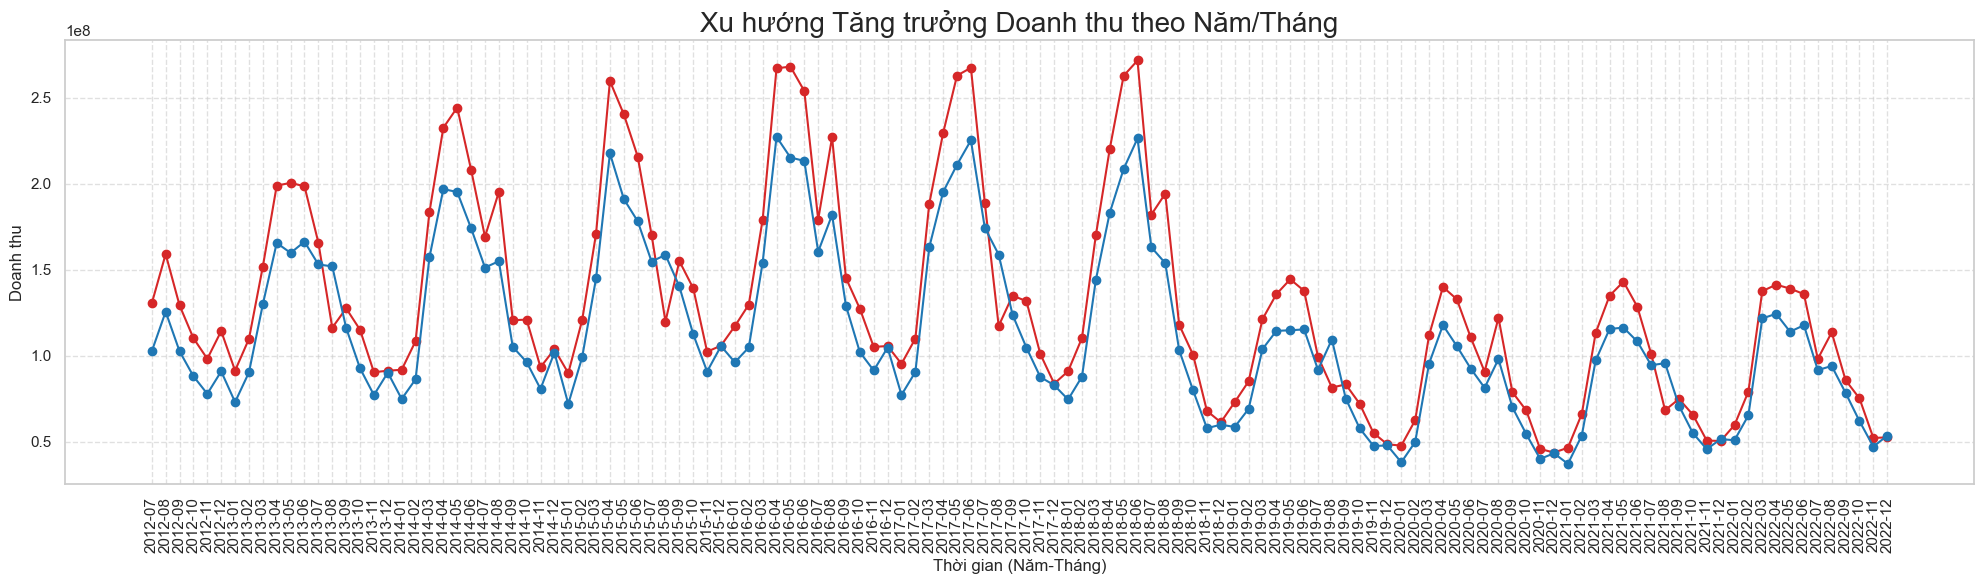

In [2]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Tạo các cột thời gian để phân tích
sales_df['year_month'] = sales_df['Date'].dt.to_period('M')      # Lấy Năm-Tháng
sales_df['day_of_week'] = sales_df['Date'].dt.dayofweek          # Lấy Thứ (0=Thứ 2, 6=Chủ nhật)
sales_df['month'] = sales_df['Date'].dt.month                    # Lấy Tháng (1 đến 12)

# Tổng hợp Doanh thu theo Năm/Tháng
trend_df = sales_df.groupby('year_month')[['Revenue', 'COGS']].sum().reset_index()
trend_df['year_month'] = trend_df['year_month'].astype(str) # Ép kiểu chuỗi để vẽ trục X đẹp hơn

fig1, ax1 = plt.subplots(figsize=(20, 6))

ax1.plot(trend_df['year_month'], trend_df['Revenue'], color='tab:red', marker='o', linestyle='-')
ax1.plot(trend_df['year_month'], trend_df['COGS'], color='tab:blue', marker='o', linestyle='-')
ax1.set_title('Xu hướng Tăng trưởng Doanh thu theo Năm/Tháng', fontsize=20)
ax1.set_xlabel('Thời gian (Năm-Tháng)')
ax1.set_ylabel('Doanh thu')
ax1.tick_params(axis='x', rotation=90)
ax1.grid(True, linestyle='--', alpha=0.6)

fig1.tight_layout()
plt.show()

#### 2. Revenue và các cột khuyến mãi

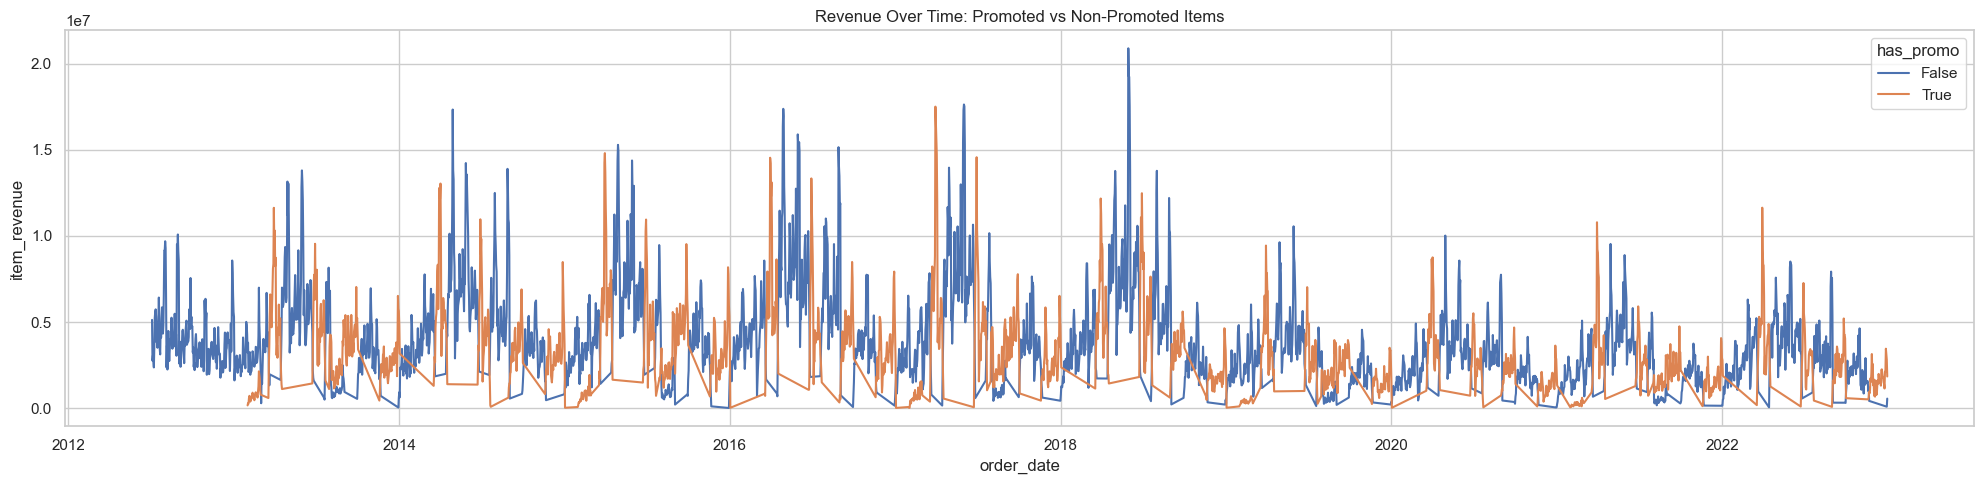

In [3]:
# Kết nối order_items với orders để lấy ngày tháng (order_date)
df = order_items_df.merge(orders_df[['order_id', 'order_date']], on='order_id', how='left')

# Tính toán doanh thu trên từng dòng sản phẩm
df['item_revenue'] = df['quantity'] * df['unit_price']

# Tạo cờ (flag) nhận diện sản phẩm có dùng khuyến mãi
df['has_promo'] = df['promo_id'].notna()

# 1. Vẽ biểu đồ chuỗi thời gian so sánh doanh thu có/không có khuyến mãi
daily_rev = df.groupby(['order_date', 'has_promo'])['item_revenue'].sum().reset_index()
daily_rev['order_date'] = pd.to_datetime(daily_rev['order_date'])

plt.figure(figsize=(20, 5))
sns.lineplot(data=daily_rev, x='order_date', y='item_revenue', hue='has_promo')
plt.title('Revenue Over Time: Promoted vs Non-Promoted Items')
plt.tight_layout()
plt.show()

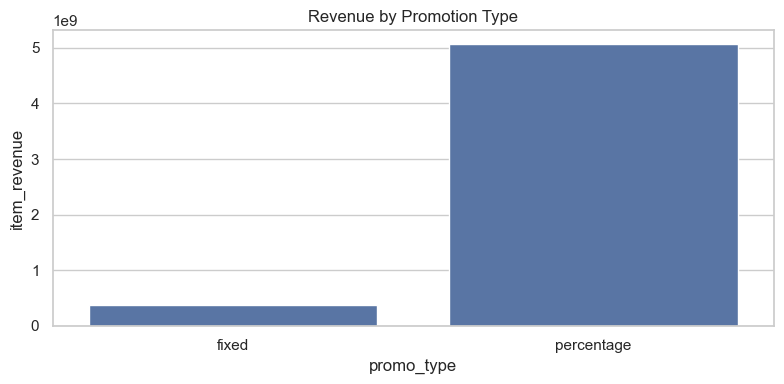

In [4]:
# 2. Phân tích doanh thu theo loại hình khuyến mãi
promo_df = df[df['has_promo']].copy()
promo_df = promo_df.merge(promotions_df[['promo_id', 'promo_type']], on='promo_id', how='left')

type_rev = promo_df.groupby('promo_type')['item_revenue'].sum().reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(data=type_rev, x='promo_type', y='item_revenue')
plt.title('Revenue by Promotion Type')
plt.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - **Biến động Doanh thu theo trạng thái khuyến mãi (Line Chart):** Khối lượng doanh thu từ các sản phẩm không áp dụng khuyến mãi (`has_promo = False`, đường màu xanh) duy trì ở mức nền cao và dày đặc hơn hẳn so với các sản phẩm có khuyến mãi (`has_promo = True`, đường màu cam) xuyên suốt từ năm 2012 đến cuối 2022. Mặc dù cả hai đều có những đỉnh (spikes) mang tính chu kỳ, các đỉnh cao nhất (chạm mốc 1.5 - 2.0 x 10^7) chủ yếu đến từ nhóm không khuyến mãi hoặc có sự đan xen chặt chẽ.
  - **Phân bổ Doanh thu theo loại hình khuyến mãi (Bar Chart):** Trong tổng doanh thu từ các giao dịch có khuyến mãi, hình thức giảm giá theo tỷ lệ phần trăm (`percentage`) vượt trội hoàn toàn. Cột `percentage` đạt mức xấp xỉ 5 tỷ, cao gấp hơn 10 lần so với hình thức giảm giá bằng số tiền cố định (`fixed` - chỉ đạt dưới mốc 0.5 tỷ).
  - **Tổng quan:** Doanh thu tự nhiên (không khuyến mãi) đóng vai trò xương sống của mảng kinh doanh, trong khi các chương trình khuyến mãi chỉ đóng vai trò bổ trợ. Khi áp dụng khuyến mãi, phương thức "giảm theo %" chiếm ưu thế tuyệt đối về mặt tạo ra doanh thu so với "giảm số tiền cố định".

- **Insights:**
  - **Sức mạnh nội tại và Nhu cầu tự nhiên (Organic Demand):** Doanh nghiệp không bị phụ thuộc vào các chương trình khuyến mãi để duy trì dòng tiền. Việc doanh thu non-promoted chiếm ưu thế cho thấy tệp khách hàng có độ trung thành cao, sản phẩm có sức hút tự thân rất tốt và khách hàng sẵn sàng chi trả ở mức giá niêm yết (full-price).
  - **Hiệu ứng tâm lý giá (Price Psychology):** Khách hàng phản ứng tích cực và nhạy cảm hơn rất nhiều với khuyến mãi theo tỷ lệ phần trăm. Việc giảm theo "%" thường tạo cảm giác "được hời" lớn hơn (đặc biệt hữu ích với các sản phẩm/giỏ hàng có giá trị cao), từ đó thúc đẩy tỷ lệ chuyển đổi (Conversion Rate) hiệu quả hơn hẳn so với các voucher giảm giá cố định.

- **Gợi ý hành động:**
  - Tiến hành phân tích chéo giữa `promo_type` (`percentage` vs `fixed`) và tỷ suất lợi nhuận (Profit Margin). Dù `percentage` mang lại doanh thu "khủng", cần kiểm tra chặt chẽ xem liệu nó có làm "ăn mòn" biên lợi nhuận (Margin Erosion) hay không để tính toán ROI thực tế của từng loại chiến dịch.
  - Kết hợp thêm chiều thời gian (Tính thời vụ/Seasonality) và Nhóm sản phẩm (Category). Xác định xem những đỉnh doanh thu (spikes) của nhóm `has_promo = True` rơi vào mùa vụ nào. Từ đó, mạnh dạn cắt giảm ngân sách cho hình thức `fixed` kém hiệu quả, dồn lực thiết kế các chiến dịch `percentage` (như Flash Sale) tại các điểm trũng doanh thu để kích cầu tối ưu mà không làm mất giá trị thương hiệu.

#### 3. Revenue và Web Traffic

#### 4. Revenue theo khu vực
- region
- city
- district

#### 5. Revenue theo Customer Segment

#### 6. Revenue vs Device Type

#### 7. Revenue vs Payment Method

#### 8. Revenue vs Delivery Speed

#### 9. Revenue vs Review Rating 

## Câu hỏi

### **Câu hỏi 1: Vì sao doanh thu tăng mạnh trong tháng 4-6?**

#### Câu hỏi nhỏ 1: Doanh thu tăng trong tháng 4-6 có ảnh hưởng bởi chương trình khuyến mãi?

#### Câu hỏi nhỏ 2: Peak tháng 4–6 có lặp lại mỗi năm không?

#### Câu hỏi nhỏ 3: Doanh thu tăng có phải phụ thuộc lưu lượng truy cập?

### **Câu hỏi 2 - Về xu hướng dài hạn (Long-term Trend): Vì sao doanh thu giảm rõ rệt sau 2018?**
#### Câu hỏi nhỏ 1: Sự sụt giảm này là do yếu tố vĩ mô (ví dụ: đại dịch COVID-19 làm đứt gãy chuỗi cung ứng/giảm sức mua) hay do thay đổi trong chiến lược kinh doanh nội bộ (giảm ngân sách Marketing, thay đổi tập khách hàng)?


#### Câu hỏi nhỏ 2: Có nên tách dữ liệu 2013-2019 và từ 2020 trở đi thành một regime (cấu trúc) riêng để phân tích không?

### **Câu hỏi 3: Tại sao có sự khác biệt doanh thu giữa những mùa xuân/hè và mùa thu/đông?**
#### Câu hỏi nhỏ 1: Doanh thu có phụ thuộc vào danh mục quần áo theo mùa? (phụ thuộc quá nhiều vào bộ sưu tập Xuân/Hè (áo thun, quần short, đồ bơi...)?)
Note: vào products xem có phải toàn dạng đồ mùa hè?



#### Câu hỏi nhỏ 2: Chúng ta có dữ liệu bóc tách cấp độ Category (ngành hàng) để chứng minh rằng mùa đông bị sụt giảm doanh thu do thiếu hụt sản phẩm phù hợp hay không?

### **Câu hỏi 4: Khuyến mãi có ảnh hưởng đến biên lợi nhuận?**
#### Câu hỏi nhỏ 1: Khi áp dụng khuyến mãi vào thời điểm nào thì tối đa hóa lợi nhuận?



### **Câu hỏi 5: Có những mặt hàng nào đem lại lợi nhuận cao trong công ty**
#### Câu hỏi nhỏ 1: Doanh thu có phụ thuộc vào danh mục quần áo theo mùa? (phụ thuộc quá nhiều vào bộ sưu tập Xuân/Hè (áo thun, quần short, đồ bơi...)?)
Note: vào products xem có phải toàn dạng đồ mùa hè?



# 2. Phân tích Cost